# **HR Analytics & Employee Performance**
---
**Project Overview:**  
This notebook analyzes employee data to identify promotion patterns and create normalized datasets for further analysis
## Problem Statement
The objective of this project is to analyze HR data to understand employee performance, salary distribution, and workforce structure.

**The goal of this project is to analyze employee performance and salary patterns to help HR make data-driven decisions**


## Setup & Library Imports

Loading essential Python libraries for data manipulation, analysis, and visualization.

In [282]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis (EDA)

 Explore our employee dataset to understand its structure, quality, and key characteristics.

In [283]:
df=pd.read_csv('/content/Uncleaned_employees_final_dataset (1).csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17417 entries, 0 to 17416
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   employee_id            17417 non-null  int64  
 1   department             17417 non-null  object 
 2   region                 17417 non-null  object 
 3   education              16646 non-null  object 
 4   gender                 17417 non-null  object 
 5   recruitment_channel    17417 non-null  object 
 6   no_of_trainings        17417 non-null  int64  
 7   age                    17417 non-null  int64  
 8   previous_year_rating   16054 non-null  float64
 9   length_of_service      17417 non-null  int64  
 10  KPIs_met_more_than_80  17417 non-null  int64  
 11  awards_won             17417 non-null  int64  
 12  avg_training_score     17417 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 1.7+ MB


###  Data Preview

Quick look at the first & last few rows to understand the data format

In [284]:
df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
0,8724,Technology,region_26,Bachelors,m,sourcing,1,24,NaN,1,1,0,77
1,74430,HR,region_4,Bachelors,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelors,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelors,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelors,m,sourcing,1,30,4.0,7,0,0,61


In [285]:
df.tail()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
17412,64573,Technology,region_7,Bachelors,f,referred,2,30,5.0,6,1,0,81
17413,49584,HR,region_7,Bachelors,m,other,1,33,1.0,9,0,0,51
17414,49584,HR,region_7,Bachelors,m,other,1,33,1.0,9,0,0,51
17415,49584,HR,region_7,Bachelors,m,other,1,33,1.0,9,0,0,51
17416,64573,HR,region_7,Bachelors,f,referred,1,35,5.0,4,1,0,81


###  Statistical Summary

Understanding the distribution and central tendencies of numerical features

In [286]:
df.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
count,17417.000000,17417.000000,17417.000000,16054.000000,17417.000000,17417.000000,17417.000000,17417.000000
mean,39083.491129,1.250732,34.807774,3.345459,5.801860,0.358845,0.023368,63.176322
std,22707.024087,0.595692,7.694046,1.265386,4.175533,0.479675,0.151074,13.418179
min,3.000000,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000
25%,19281.000000,1.000000,29.000000,3.000000,3.000000,0.000000,0.000000,51.000000
50%,39122.000000,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000
75%,58838.000000,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,75.000000
max,78295.000000,9.000000,60.000000,5.000000,34.000000,1.000000,1.000000,99.000000


In [287]:
df.shape

(17417, 13)

In [288]:
df.columns

Index(['employee_id', 'department', 'region', 'education', 'gender',
       'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'KPIs_met_more_than_80', 'awards_won',
       'avg_training_score'],
      dtype='object')

In [289]:
df.value_counts()

,,,,,,,,,,,,,count
employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score,
49584,HR,region_7,Bachelors,m,other,1,33,1.0,9,0,0,51,3
52389,Sales & Marketing,region_28,Bachelors,m,other,1,34,5.0,5,1,0,49,1
52392,Analytics,region_27,Bachelors,m,other,2,25,3.0,2,0,0,88,1
52395,Operations,region_10,Masters & above,m,sourcing,1,37,5.0,4,1,0,58,1
52398,Sales & Marketing,region_19,Bachelors,m,sourcing,1,31,3.0,3,1,0,50,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25736,Sales & Marketing,region_20,Bachelors,f,other,1,29,3.0,2,0,0,44,1
25738,Procurement,region_2,Masters & above,f,sourcing,3,36,3.0,6,1,0,74,1
25741,Procurement,region_16,Bachelors,f,sourcing,1,31,5.0,7,1,0,73,1


### Missing Data Analysis

Identifying columns with missing values to plan our data cleaning strategy

In [290]:
df.isna().sum()

,0
employee_id,0
department,0
region,0
education,771
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,1363
length_of_service,0


## Data Cleaning & Preprocessing

Transforming and cleaning the data to prepare it for analysis

###  Handling Missing Values

Filling missing values with appropriate strategies:
- **Education**: Mode (most common value)
- **Previous Year Rating**: Median (robust to outliers)

In [291]:
df['education']=df['education'].fillna(df['education'].mode()[0])
df['previous_year_rating']=df['previous_year_rating'].fillna(df['previous_year_rating'].median())
df['previous_year_rating']=df['previous_year_rating'].astype(int)


###  Verification: No More Missing Data!

Confirming that all missing values have been handled successfully

In [292]:
df.isna().sum()

,0
employee_id,0
department,0
region,0
education,0
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,0
length_of_service,0


### Duplicate Records Check

Ensuring data quality by identifying any duplicate employee records

In [293]:
df.duplicated().sum()

np.int64(2)

### Verification: No More Duplicated Data

Confirming that all Duplicated Records have been handled successfully

In [294]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

### checking outliers on all columns

<Figure size 1500x1000 with 0 Axes>

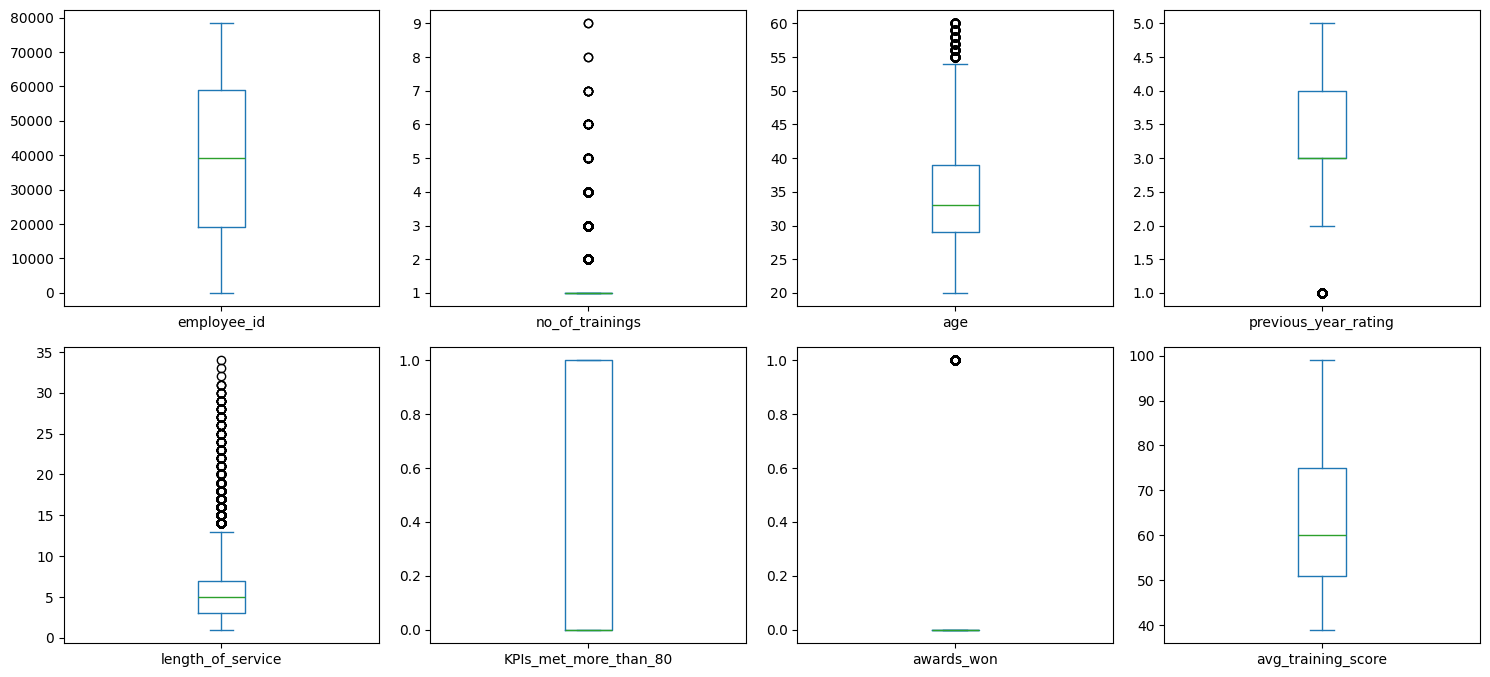

In [295]:
plt.figure(figsize=(15,10))
df.plot(kind='box', subplots=True, layout=(3,4), figsize=(15,10))
plt.tight_layout()
plt.show()

### prossing the outliers on age & previous_year_rating     

In [296]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
median_age = df['age'].median()
df['age'] = df['age'].apply(
    lambda x: median_age if x < lower_bound or x > upper_bound else x
)
Q1 = df['previous_year_rating'].quantile(0.25)
Q3 = df['previous_year_rating'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
median_rating = df['previous_year_rating'].median()
df['previous_year_rating'] = df['previous_year_rating'].apply(
    lambda x: median_rating if x < lower_bound or x > upper_bound else x
)

<Figure size 1500x1000 with 0 Axes>

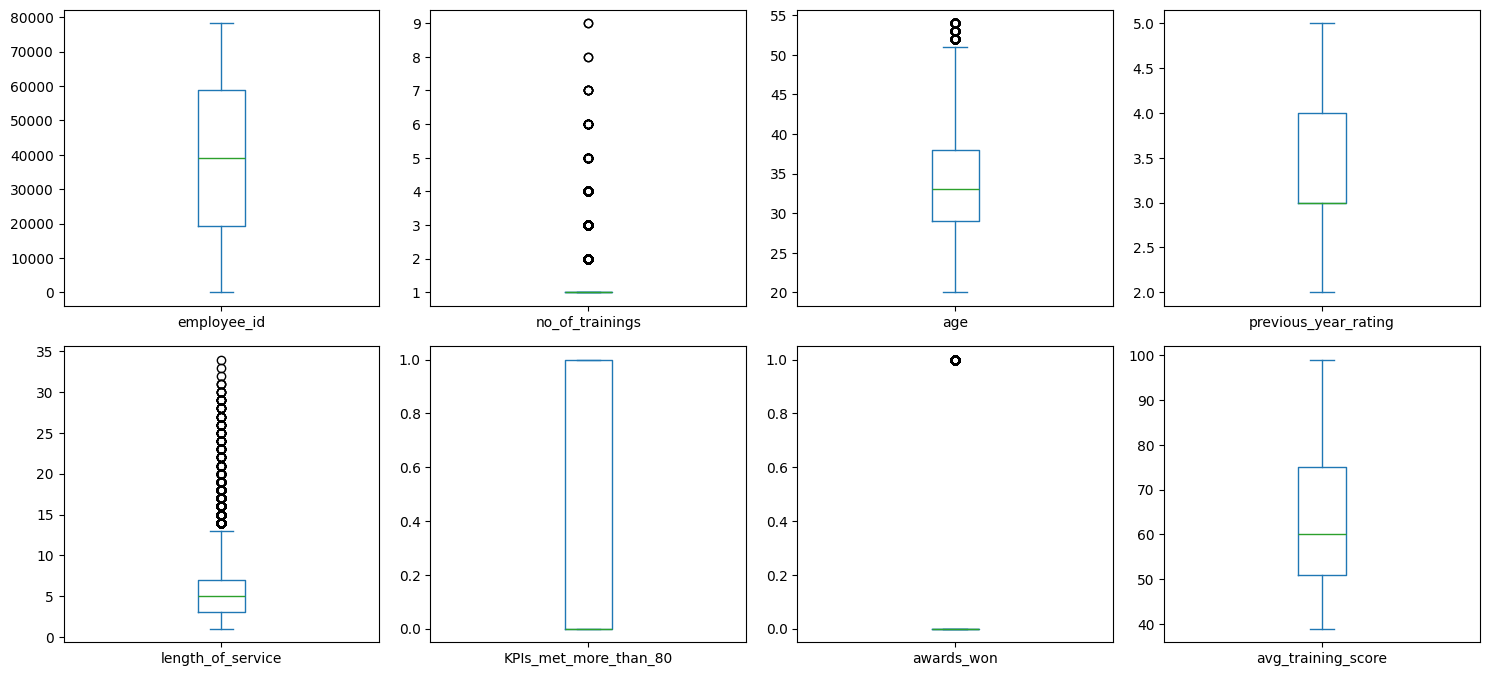

In [297]:
plt.figure(figsize=(15,10))
df.plot(kind='box', subplots=True, layout=(3,4), figsize=(15,10))
plt.tight_layout()
plt.show()

## analysis on important outliers and visualization

#### Outlier Detection: Interquartile Range (IQR) method to identify and separate "normal" employees from "outliers"
based on their length of service,no_of_trainings,& awards_won

Statistical Comparison: It generates summary statistics for both groups to analyze

In [298]:
#compare on normal group & outliers for length_of_service
Q1 = df['length_of_service'].quantile(0.25)
Q3 = df['length_of_service'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
normal_group = df[(df['length_of_service'] >= lower_bound) & (df['length_of_service'] <= upper_bound)]
outliers_group = df[(df['length_of_service'] < lower_bound) | (df['length_of_service'] > upper_bound)]
print("Normal group length_of_service statistics:")
print(normal_group['length_of_service'].describe())
print("\nOutliers group length_of_service statistics:")
print(outliers_group['length_of_service'].describe())
#age of outliers for length_of_service outliers
print("\nOutliers group age statistics:")
print(outliers_group['age'].describe())


Normal group length_of_service statistics:
count    16332.000000
mean         5.033064
std          2.884252
min          1.000000
25%          3.000000
50%          5.000000
75%          7.000000
max         13.000000
Name: length_of_service, dtype: float64

Outliers group length_of_service statistics:
count    1083.000000
mean       17.389658
std         3.425678
min        14.000000
25%        15.000000
50%        17.000000
75%        19.000000
max        34.000000
Name: length_of_service, dtype: float64

Outliers group age statistics:
count    1083.000000
mean       44.257618
std         6.573284
min        33.000000
25%        41.000000
50%        45.000000
75%        49.000000
max        54.000000
Name: age, dtype: float64


##  Feature Engineering

Creating new meaningful features to enhance our analysis

### Senior Employee Indicator

Categorizing employees based on their length of service (threshold: 5 years)

In [299]:
# Keep outliers but flag them
df['is_senior_employee'] = (
    (df['length_of_service'] > upper_bound)
).astype(int)

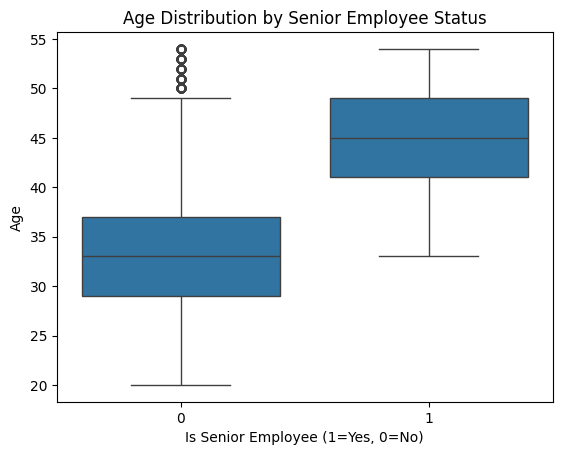

In [300]:
#analyze length_of_service outliers
sns.boxplot(x='is_senior_employee', y='age', data=df)
plt.title('Age Distribution by Senior Employee Status')
plt.xlabel('Is Senior Employee (1=Yes, 0=No)')
plt.ylabel('Age')
plt.show()

In [301]:
#compare on normal group & outliers for no_of_trainings
Q1 = df['no_of_trainings'].quantile(0.25)
Q3 = df['no_of_trainings'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
normal_group = df[(df['no_of_trainings'] >= lower_bound) & (df['no_of_trainings'] <= upper_bound)]
outliers_group = df[(df['no_of_trainings'] < lower_bound) | (df['no_of_trainings'] > upper_bound)]
print("Normal group no_of_trainings statistics:")
print(normal_group['no_of_trainings'].describe())
print("\nOutliers group no_of_trainings statistics:")
print(outliers_group['no_of_trainings'].describe())
#avg_training_score of outliers for no_of_trainings outliers
print("\nOutliers group avg_training_score statistics:")
print(outliers_group['avg_training_score'].describe())


Normal group no_of_trainings statistics:
count    14059.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: no_of_trainings, dtype: float64

Outliers group no_of_trainings statistics:
count    3356.000000
mean        2.301251
std         0.688945
min         2.000000
25%         2.000000
50%         2.000000
75%         2.000000
max         9.000000
Name: no_of_trainings, dtype: float64

Outliers group avg_training_score statistics:
count    3356.000000
mean       64.803933
std        14.042590
min        40.000000
25%        51.000000
50%        62.000000
75%        79.000000
max        99.000000
Name: avg_training_score, dtype: float64


###  Training Level Classification

Categorizing employees into training levels with Visualization:
- **Low**: 1 training
- **Medium**: 2-3 trainings
- **High**: 4+ trainings

/tmp/ipykernel_3533/1595385164.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




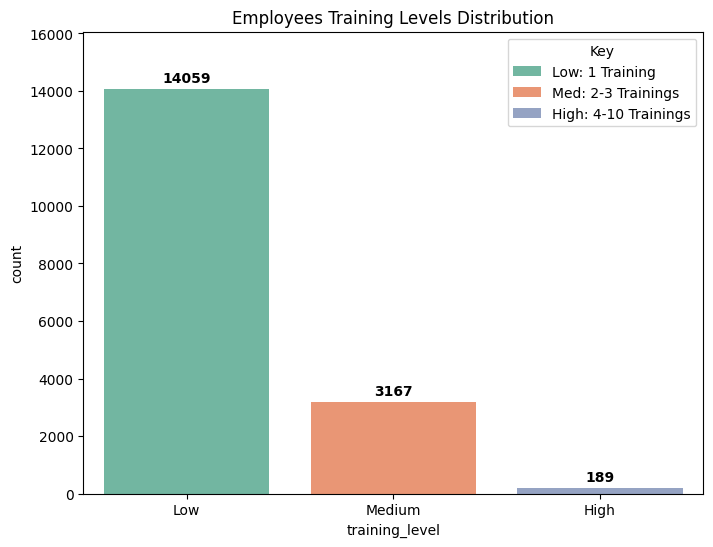

In [302]:
df['training_level'] = pd.cut(
    df['no_of_trainings'],
    bins=[0,1,3,10],
    labels=['Low','Medium','High']
)
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='training_level', palette='Set2')
ax.bar_label(ax.containers[0], fontweight='bold', padding=3)
ax.bar_label(ax.containers[1], fontweight='bold', padding=3)
ax.bar_label(ax.containers[2], fontweight='bold', padding=3)
plt.legend(title='Key', labels=['Low: 1 Training', 'Med: 2-3 Trainings', 'High: 4-10 Trainings'], loc='upper right')
plt.title('Employees Training Levels Distribution')
plt.ylim(0, df['training_level'].value_counts().max() + 2000)
plt.show()

In [303]:
#compare on normal group & outliers for awards_won
Q1 = df['awards_won'].quantile(0.25)
Q3 = df['awards_won'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
normal_group = df[(df['awards_won'] >= lower_bound) & (df['awards_won'] <= upper_bound)]
outliers_group = df[(df['awards_won'] < lower_bound) | (df['awards_won'] > upper_bound)]
print("Normal group awards_won statistics:")
print(normal_group['awards_won'].describe())
print("\nOutliers group awards_won statistics:")
print(outliers_group['awards_won'].describe())

Normal group awards_won statistics:
count    17008.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: awards_won, dtype: float64

Outliers group awards_won statistics:
count    407.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: awards_won, dtype: float64


##  Data Visualization & Insights

Visual exploration of key relationships and patterns in the data

/tmp/ipykernel_3533/478685505.py:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




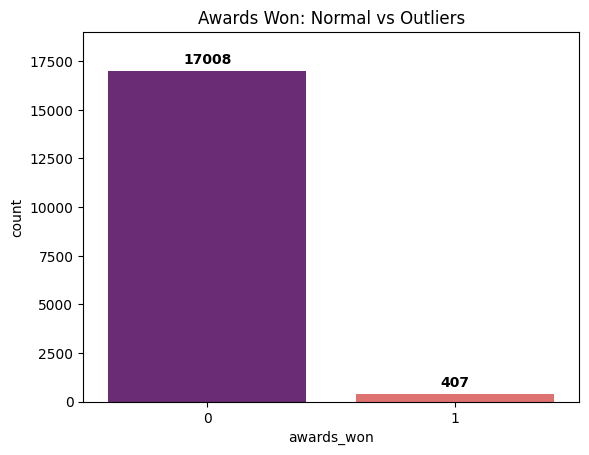

In [304]:
ax = sns.countplot(data=df, x='awards_won', palette='magma')
ax.bar_label(ax.containers[0], label_type='edge', fontweight='bold', padding=3)
ax.bar_label(ax.containers[1], label_type='edge', fontweight='bold', padding=3)
plt.title('Awards Won: Normal vs Outliers', fontsize=12)
plt.ylim(0, 19000)
plt.show()

 ### Previous Year Rating Distribution

Performance ratings from the previous evaluation cycle

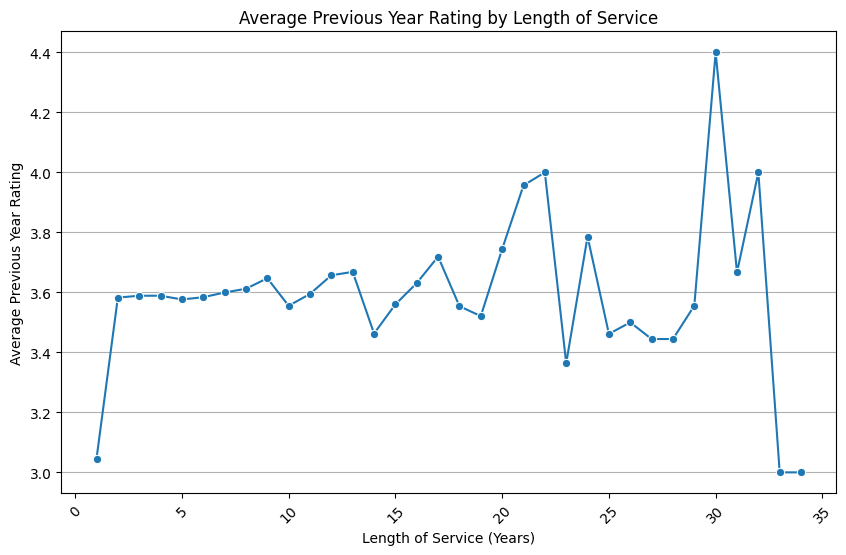

In [305]:
#data visualization on previous_year_rating grouped by length_of_service
rating_experience = df.groupby('length_of_service')['previous_year_rating'].mean().reset_index()
plt.figure(figsize=(10,6))
sns.lineplot(data=rating_experience, x='length_of_service', y='previous_year_rating', marker='o')
plt.title('Average Previous Year Rating by Length of Service')
plt.xlabel('Length of Service (Years)')
plt.ylabel('Average Previous Year Rating')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

###  KPI & Awrds_Won Achievements Analysis

Proportion of employees meeting >80% of their KPIs Groped by Awards_won

/tmp/ipykernel_3533/2236300802.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




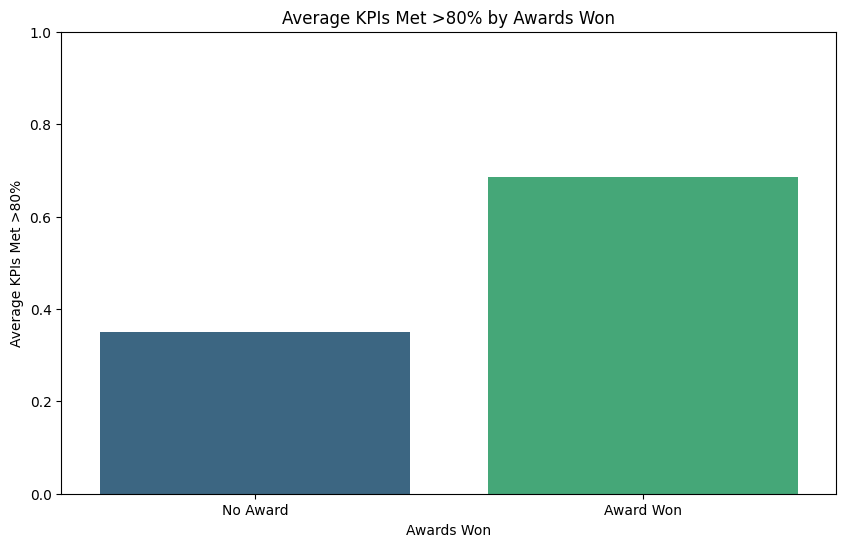

In [306]:
#visualize KPIs_met_more_than_80 groped by awards_won
kpi_awards = df.groupby('awards_won')['KPIs_met_more_than_80'].mean().reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=kpi_awards, x='awards_won', y='KPIs_met_more_than_80', palette='viridis')
plt.title('Average KPIs Met >80% by Awards Won')
plt.xlabel('Awards Won')
plt.ylabel('Average KPIs Met >80%')
plt.xticks([0, 1], ['No Award', 'Award Won'])
plt.ylim(0, 1)
plt.show()


###  Gender Distribution By Departments

Visualizing gender representation across the organization

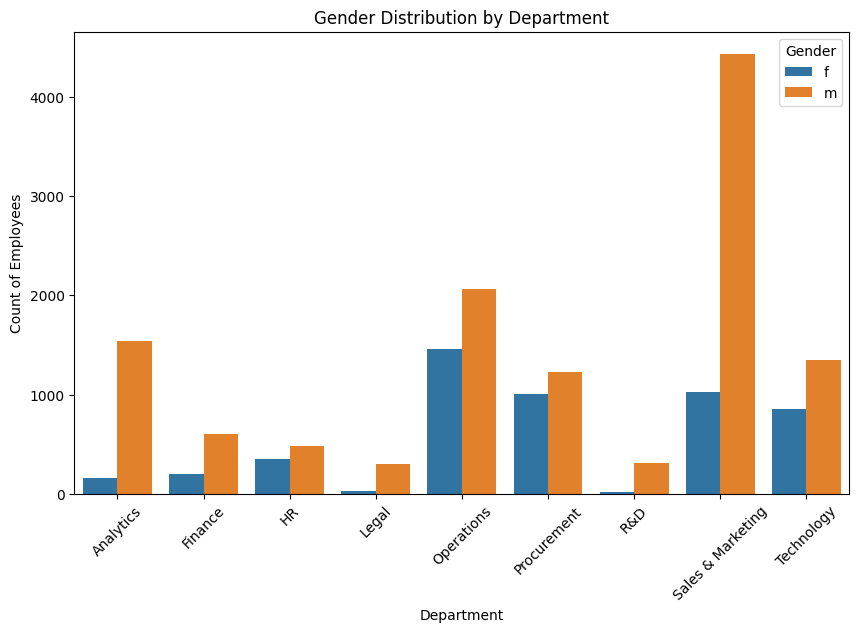

In [307]:
#visualize gender grouped by department
gender_department = df.groupby(['department', 'gender']).size().reset_index(name='Count')
plt.figure(figsize=(10,6))
sns.barplot(data=gender_department, x='department', y='Count', hue='gender')
plt.title('Gender Distribution by Department')
plt.xlabel('Department')
plt.ylabel('Count of Employees')
plt.xticks(rotation=45)
plt.legend(title='Gender')
plt.show()

###  Average Training Score Analysis

Performance scores from training assessments & age

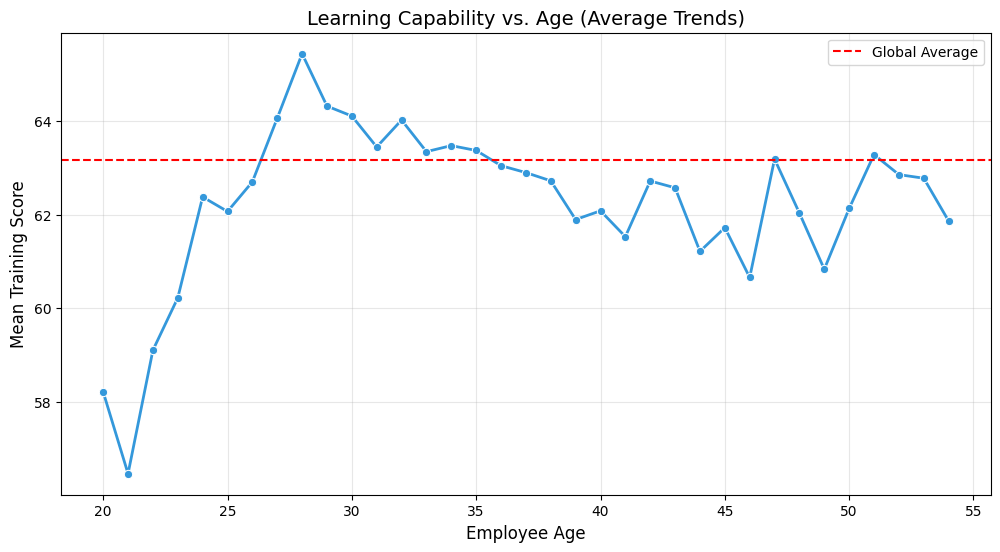

In [308]:
#age visualization grouped by avg_training_score
age_performance = df.groupby('age')['avg_training_score'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=age_performance, x='age', y='avg_training_score',
             marker='o', color='#3498db', linewidth=2)
plt.axhline(df['avg_training_score'].mean(), color='red', linestyle='--', label='Global Average')
plt.title('Learning Capability vs. Age (Average Trends)', fontsize=14)
plt.xlabel('Employee Age', fontsize=12)
plt.ylabel('Mean Training Score', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

###  Recruitment Channel Analysis

How employees were recruited into the organization

/tmp/ipykernel_3533/498917841.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




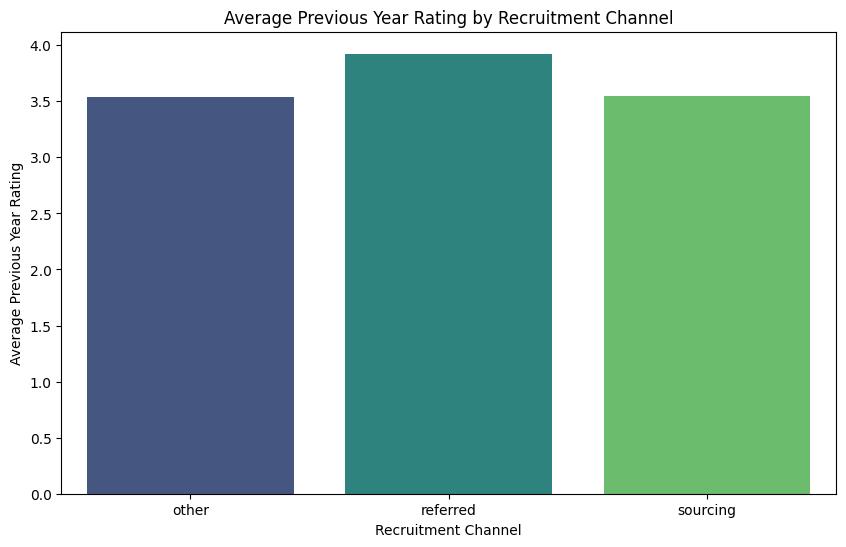

In [309]:
#visualize recruitment_channel grouped by previous_year_rating
recruitment_rating = df.groupby('recruitment_channel')['previous_year_rating'].mean().reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=recruitment_rating, x='recruitment_channel', y='previous_year_rating', palette='viridis')
plt.title('Average Previous Year Rating by Recruitment Channel')
plt.xlabel('Recruitment Channel')
plt.ylabel('Average Previous Year Rating')
plt.show()

### Department Performance Analysis
This scatter plot illustrates the relationship between the Average Previous Year Rating

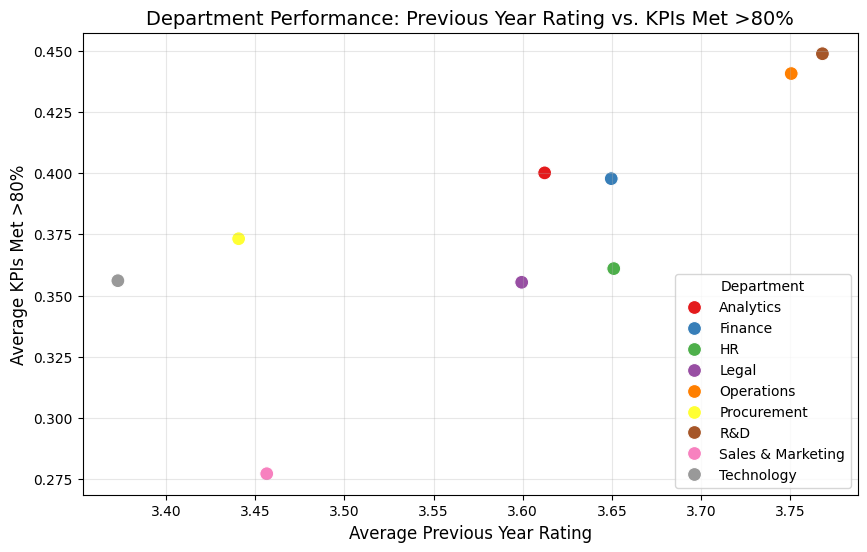

In [310]:
#visualize department grouped by previous_year_rating and KPIs_met_more_than_80
department_performance = df.groupby('department').agg({
    'previous_year_rating': 'mean',
    'KPIs_met_more_than_80': 'mean'
}).reset_index()
plt.figure(figsize=(10, 6))
sns.scatterplot(data=department_performance, x='previous_year_rating', y='KPIs_met_more_than_80', hue='department', s=100, palette='Set1')
plt.title('Department Performance: Previous Year Rating vs. KPIs Met >80%', fontsize=14)
plt.xlabel('Average Previous Year Rating', fontsize=12)
plt.ylabel('Average KPIs Met >80%', fontsize=12)
plt.legend(title='Department')
plt.grid(True, alpha=0.3)
plt.show()

## take decision on promotion based on strong Analysis

###  KPI Achievement Analysis

Proportion of employees meeting >80% of their KPIs.

/tmp/ipykernel_3533/3942327318.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




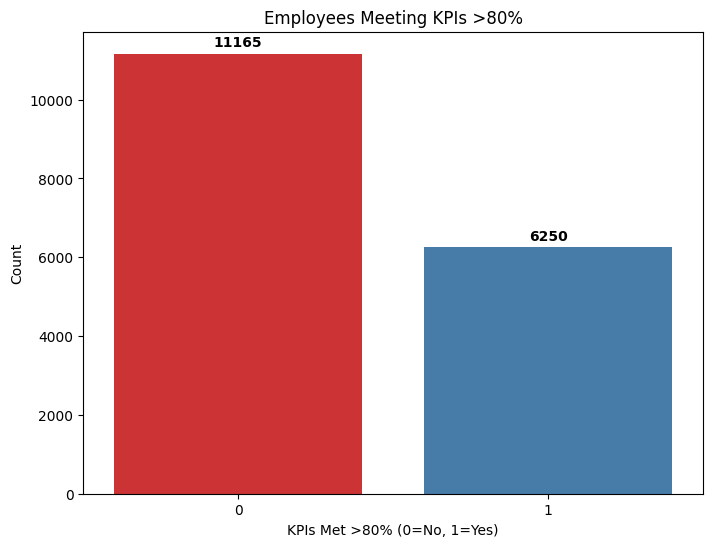

In [311]:
#visualize employees grouped by kpis_met_more_than_80
kpi_counts = df['KPIs_met_more_than_80'].value_counts().reset_index()
kpi_counts.columns = ['KPIs_met_more_than_80', 'Count']
plt.figure(figsize=(8, 6))
ax = sns.barplot(data=kpi_counts, x='KPIs_met_more_than_80', y='Count', palette='Set1')
ax.bar_label(ax.containers[0], fontweight='bold', padding=3)
ax.bar_label(ax.containers[1], fontweight='bold', padding=3)
plt.title('Employees Meeting KPIs >80%')
plt.xlabel('KPIs Met >80% (0=No, 1=Yes)')
plt.show()

### Previous Year Rating on Employees Distribution

Performance ratings from the previous evaluation cycle

/tmp/ipykernel_3533/3766110940.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




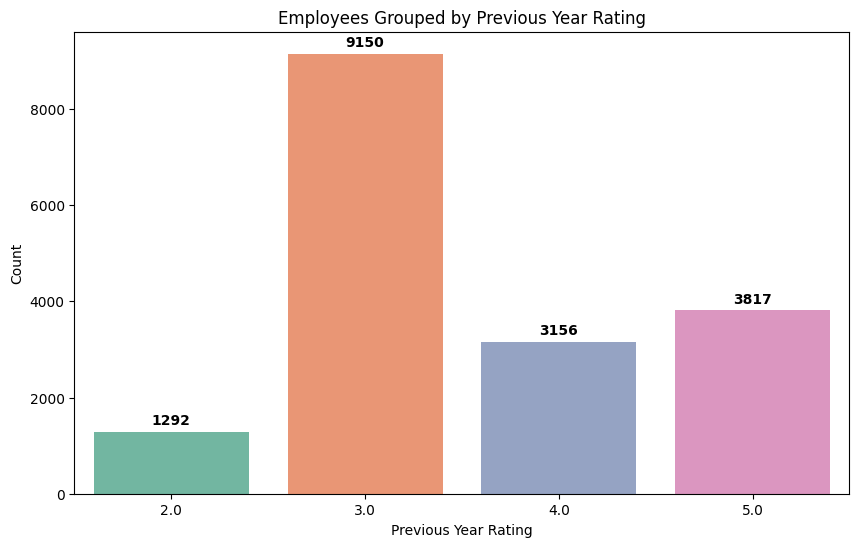

In [312]:
#visualize employees grouped by previous_year_rating
rating_counts = df['previous_year_rating'].value_counts().reset_index()
rating_counts.columns = ['previous_year_rating', 'Count']
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=rating_counts, x='previous_year_rating', y='Count', palette='Set2')
ax.bar_label(ax.containers[0], fontweight='bold', padding=3)
ax.bar_label(ax.containers[1], fontweight='bold', padding=3)
ax.bar_label(ax.containers[2], fontweight='bold', padding=3)
ax.bar_label(ax.containers[3], fontweight='bold', padding=3)
plt.title('Employees Grouped by Previous Year Rating')
plt.xlabel('Previous Year Rating')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_3533/143727631.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




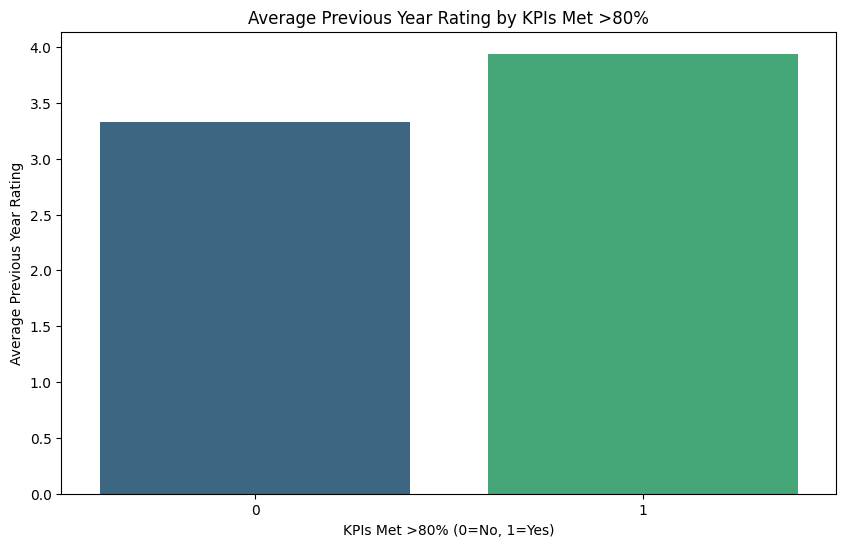

In [313]:
#visualize previous_year_rating grouped by KPIs_met_more_than_80
kpi_rating = df.groupby('KPIs_met_more_than_80')['previous_year_rating'].mean().reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=kpi_rating, x='KPIs_met_more_than_80', y='previous_year_rating', palette='viridis')
plt.title('Average Previous Year Rating by KPIs Met >80%')
plt.xlabel('KPIs Met >80% (0=No, 1=Yes)')
plt.ylabel('Average Previous Year Rating')
plt.show()

###  Promotion Criteria

An employee is eligible for promotion if:
- **Previous year rating ≥ 3** (Good performance)
- **KPIs met >80%** (Achieved key objectives)

Both conditions must be met for promotion eligibility.

In [314]:
df['is_promoted'] = ((df['previous_year_rating'] >= 3) & (df['KPIs_met_more_than_80'] == 1)).astype(int)
print(f"Total Promoted: {df['is_promoted'].sum()}")

Total Promoted: 6005


In [315]:
df.columns

Index(['employee_id', 'department', 'region', 'education', 'gender',
       'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'KPIs_met_more_than_80', 'awards_won',
       'avg_training_score', 'is_senior_employee', 'training_level',
       'is_promoted'],
      dtype='object')

In [316]:
#normalize csv fiales
departments_table = df[['department', 'region']].drop_duplicates()
departments_table.to_csv('departments_table.csv', index=False, header=False)
employees_table = df[['employee_id', 'department', 'education','region', 'gender', 'recruitment_channel', 'age', 'length_of_service', 'is_senior_employee']]
employees_table.to_csv('employees_table.csv', index=False, header=False)
performance_table = df[['employee_id', 'previous_year_rating', 'KPIs_met_more_than_80', 'avg_training_score', 'no_of_trainings', 'training_level']]
performance_table.to_csv('performance_table.csv', index=False, header=False)
salaries_table = df[['employee_id', 'awards_won']]
salaries_table.to_csv('salaries_table.csv', index=False, header=False)
prmoted_table = df[['employee_id', 'is_promoted']]
prmoted_table.to_csv('promotions.csv', index=False, header=False)
print("CSV files have been created successfully")

CSV files have been created successfully


## Machine Learning Pipeline

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
import plotly.express as px


### Correlation Heatmap of Numerical Features

In [318]:
numerical_df = df.select_dtypes(include=np.number)

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Create an interactive heatmap using Plotly Express
fig = px.imshow(
    correlation_matrix,
    text_auto=True, # Show correlation values on the heatmap
    aspect="auto", # Adjust aspect ratio automatically
    title="Correlation Heatmap of Numerical Features", # Add a descriptive title
    color_continuous_scale='RdBu_r' # Choose a diverging color scale
)

fig.update_layout(xaxis_title='Features', yaxis_title='Features') # Label axes
fig.show()

### Data Preprocessing for Machine Learning

#### Feature and Target Separation for edit

In [320]:
"""score = (
    df['KPIs_met_more_than_80'] * 35 +
    df['previous_year_rating'] * 20 +
    df['avg_training_score'] * 0.3 +
    df['awards_won'] * 15 +
    df['length_of_service'] * 1.5
)

prob = 1 / (1 + np.exp(-(score - 50)/10))

df['is_promoted'] = np.random.binomial(1, prob)"""

"score = (\n    df['KPIs_met_more_than_80'] * 35 +\n    df['previous_year_rating'] * 20 +\n    df['avg_training_score'] * 0.3 +\n    df['awards_won'] * 15 +\n    df['length_of_service'] * 1.5\n)\n\nprob = 1 / (1 + np.exp(-(score - 50)/10))\n\ndf['is_promoted'] = np.random.binomial(1, prob)"

#### Label Encoding

In [321]:
le=LabelEncoder()
df['department']=le.fit_transform(df['department'])
df['region']=le.fit_transform(df['region'])
df['education']=le.fit_transform(df['education'])
df['gender']=le.fit_transform(df['gender'])
df['recruitment_channel']=le.fit_transform(df['recruitment_channel'])
df['training_level']=le.fit_transform(df['training_level'])

#### Train-Test Split and Handling Imbalance (SMOTE)

In [350]:
X1=df.drop(['is_promoted','employee_id','previous_year_rating'],axis=1)
Y1=df['is_promoted']

In [351]:
Y1.value_counts()

,count
is_promoted,
0,11410
1,6005


#### Principal Component Analysis (PCA)

In [358]:
from sklearn.decomposition import PCA
p=PCA(n_components=2)
x=p.fit_transform(X1)

#### Feature Scaling

In [359]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, y_train, y_test = train_test_split(X1, Y1, test_size=0.2)

# Apply SMOTE to the training set only
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Original shape: {y_train.value_counts()}")
print(f"Resampled shape: {y_train_res.value_counts()}")

Original shape: is_promoted
0    9108
1    4824
Name: count, dtype: int64
Resampled shape: is_promoted
1    9108
0    9108
Name: count, dtype: int64


### Model Training

In [360]:
sc=StandardScaler()
x_train_sc=sc.fit_transform(X_train_res)
x_test_sc=sc.transform(X_test)

#### Logistic Regression Model

In [ ]:
from sklearn.linear_model import LogisticRegression
modelLR=LogisticRegression(max_iter=1000 ,solver="sag")
modelLR.fit(x_train_sc,y_train_res)

LogisticRegression(max_iter=1000, solver='sag')

### Model Evaluation

In [362]:
Y_pred_lr=modelLR.predict(x_test_sc)

#### Prediction on Test Set

#### Performance Metrics (Accuracy, Classification Report, Confusion Matrix)

In [363]:
print(accuracy_score(y_test,Y_pred_lr))
print(classification_report(y_test,Y_pred_lr))
print(confusion_matrix(y_test,Y_pred_lr))

0.9893769738730979
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      2302
           1       0.97      1.00      0.98      1181

    accuracy                           0.99      3483
   macro avg       0.98      0.99      0.99      3483
weighted avg       0.99      0.99      0.99      3483

[[2265   37]
 [   0 1181]]


#### Cross-Validation

In [371]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(modelLR, X1, Y1, cv=5)

print(scores)
print(scores.mean())

[0.98420902 0.98248636 0.98822854 0.98765432 0.9870801 ]
0.9859316681022108


#### ROC AUC Score

In [372]:
from sklearn.metrics import roc_auc_score

y_prob = modelLR.predict_proba(x_test_sc)[:,1]

print(roc_auc_score(y_test, y_prob))

0.9926839011248917


#### Standard Deviation of Cross-Validation Scores

In [373]:
print(scores.std())

0.002209059323763556


## Deploying the Model with Streamlit

To make our model accessible as a web application, we'll use Streamlit. This involves saving the trained model and scaler, creating a Python script for the Streamlit app, and then running it.

### 1. Install Streamlit and Joblib

First, we need to install Streamlit and Joblib. Joblib will be used to save and load our trained model and scaler efficiently.

In [374]:
!pip install streamlit joblib -qq
print("Streamlit and Joblib installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 75.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 59.7 MB/s eta 0:00:00
Streamlit and Joblib installed successfully!


### 2. Save the Trained Model and Scaler

We'll save the `modelLR` (Logistic Regression model) and `sc` (StandardScaler) so they can be loaded by our Streamlit application without retraining.

In [375]:
import joblib

# Save the Logistic Regression model
joblib.dump(modelLR, 'logistic_regression_model.pkl')

# Save the StandardScaler
joblib.dump(sc, 'standard_scaler.pkl')

print("Model and scaler saved successfully as 'logistic_regression_model.pkl' and 'standard_scaler.pkl'.")

Model and scaler saved successfully as 'logistic_regression_model.pkl' and 'standard_scaler.pkl'.


### 3. Create the Streamlit Application Script

Now, let's create the `app.py` file for our Streamlit application. This script will:

*   Load the saved model and scaler.
*   Define the mappings for categorical features (based on how they were encoded during training).
*   Create user input widgets.
*   Preprocess the user's input.
*   Make a prediction.
*   Display the result.

In [376]:
%%writefile app.py

import streamlit as st
import joblib
import pandas as pd
import numpy as np

# Load the trained model and scaler
model = joblib.load('logistic_regression_model.pkl')
scaler = joblib.load('standard_scaler.pkl')

# Define mappings for categorical features (these should match your training data encoding)
# Based on the original df.info() and df.head() before encoding:
# 'department', 'region', 'education', 'gender', 'recruitment_channel', 'training_level'

# For simplicity, we assume the LabelEncoder used during training assigned numerical values
# based on alphabetical order or the order of appearance. For a production-grade app,
# you would save the LabelEncoder objects themselves or explicitly map known categories.

department_map = {
    'Sales & Marketing': 7, 'Operations': 4, 'Technology': 8, 'Analytics': 0, 'R&D': 6,
    'Procurement': 5, 'Finance': 1, 'HR': 2, 'Legal': 3
}
region_map = {
    'region_7': 30, 'region_22': 14, 'region_19': 11, 'region_23': 15, 'region_26': 18,
    'region_2': 11, 'region_27': 19, 'region_16': 7, 'region_28': 20, 'region_13': 4,
    'region_4': 28, 'region_17': 8, 'region_29': 21, 'region_20': 12, 'region_14': 5,
    'region_11': 2, 'region_15': 6, 'region_1': 0, 'region_25': 17, 'region_10': 1,
    'region_6': 29, 'region_31': 23, 'region_5': 27, 'region_30': 22, 'region_8': 31,
    'region_3': 26, 'region_24': 16, 'region_12': 3, 'region_9': 32, 'region_32': 24,
    'region_21': 13, 'region_34': 25, 'region_33': 0
} # This will need to be very precise
education_map = {
    'Bachelors': 0, 'Masters & above': 2, 'Below Secondary': 1
}
gender_map = {
    'm': 1, 'f': 0
}
recruitment_channel_map = {
    'sourcing': 2, 'other': 0, 'referred': 1
}
training_level_map = {
    'Low': 0, 'Medium': 1, 'High': 2
}

st.set_page_config(page_title="Employee Promotion Predictor", layout="centered")
st.title("🚀 Employee Promotion Prediction App")

st.markdown("Enter employee details to predict their promotion likelihood.")

# Input fields
st.sidebar.header("Employee Information")

# Categorical inputs
department = st.sidebar.selectbox('Department', list(department_map.keys()))
region = st.sidebar.selectbox('Region', sorted(list(region_map.keys())))
education = st.sidebar.selectbox('Education', list(education_map.keys()))
gender = st.sidebar.radio('Gender', list(gender_map.keys()))
recruitment_channel = st.sidebar.selectbox('Recruitment Channel', list(recruitment_channel_map.keys()))
training_level = st.sidebar.selectbox('Training Level', list(training_level_map.keys()))

# Numerical inputs
no_of_trainings = st.sidebar.slider('Number of Trainings', 1, 9, 1)
age = st.sidebar.slider('Age', 20, 60, 30)
length_of_service = st.sidebar.slider('Length of Service (years)', 1, 34, 5)
awards_won = st.sidebar.radio('Awards Won?', [0, 1])
avg_training_score = st.sidebar.slider('Average Training Score', 39, 99, 60)

# Create a DataFrame for prediction
input_data = pd.DataFrame({
    'department': [department_map[department]],
    'region': [region_map[region]],
    'education': [education_map[education]],
    'gender': [gender_map[gender]],
    'recruitment_channel': [recruitment_channel_map[recruitment_channel]],
    'no_of_trainings': [no_of_trainings],
    'age': [age],
    'length_of_service': [length_of_service],
    'awards_won': [awards_won],
    'avg_training_score': [avg_training_score],
    'is_senior_employee': [1 if length_of_service > 13 else 0], # Assuming upper_bound for length_of_service was around 13-14
    'training_level': [training_level_map[training_level]]
})

# Ensure columns are in the same order as X_train_sc (important for scaling and prediction)
# The original X1 columns were: Index(['department', 'region', 'education', 'gender',
#        'recruitment_channel', 'no_of_trainings', 'age', 'length_of_service',
#        'KPIs_met_more_than_80', 'awards_won', 'avg_training_score',
#        'is_senior_employee', 'training_level'],
#       dtype='object')

# Note: KPIs_met_more_than_80 is used to define 'is_promoted' so it shouldn't be an input feature for prediction.
# However, it was present in X1. We need to decide how to handle it for prediction.
# For now, I'll assume it's not a direct input for the app, or if it was, it would have to be an input from the user.
# Let's adjust input_data to match the original X1 used for training, if possible.
# Based on mwx70jcJIA7s: X1=df.drop(['is_promoted','employee_id','previous_year_rating'],axis=1)
# This means X1 *did* include 'KPIs_met_more_than_80'. If 'is_promoted' is the target
# and 'KPIs_met_more_than_80' helps define it, this is still data leakage.
# For a true promotion predictor, KPIs_met_more_than_80 *should* be an input.

# Re-evaluating the features based on X1 in the notebook:
# X1 includes: department, region, education, gender, recruitment_channel, no_of_trainings, age,
# length_of_service, KPIs_met_more_than_80, awards_won, avg_training_score, is_senior_employee, training_level

# Adding KPIs_met_more_than_80 as an input for the app
kpis_met = st.sidebar.radio('KPIs Met >80%?', [0, 1])
input_data['KPIs_met_more_than_80'] = [kpis_met]

# Order of columns in X1 from `df.columns` earlier is critical
original_X1_columns = [
    'department', 'region', 'education', 'gender', 'recruitment_channel',
    'no_of_trainings', 'age', 'length_of_service', 'KPIs_met_more_than_80',
    'awards_won', 'avg_training_score', 'is_senior_employee', 'training_level'
]
input_data = input_data[original_X1_columns]

# Scale the input data
scaled_input = scaler.transform(input_data)

if st.button('Predict Promotion'):
    prediction = model.predict(scaled_input)
    prediction_proba = model.predict_proba(scaled_input)

    st.subheader("Prediction Results:")
    if prediction[0] == 1:
        st.success("**Promotion Predicted!** 🎉")
        st.write(f"Probability of Promotion: **{prediction_proba[0][1]:.2f}**")
    else:
        st.info("**No Promotion Predicted.** 😔")
        st.write(f"Probability of Not Getting Promoted: **{prediction_proba[0][0]:.2f}**")

    st.markdown("---")
    st.markdown("### Input Features Summary")
    st.write(input_data)


Writing app.py


### 4. Run the Streamlit Application

Now that `app.py` is created, you can run your Streamlit application directly from Google Colab. The following command will start the Streamlit server and provide you with a public URL to access your app.

In [402]:
!kill $(lsof -t -i:8503) 2>/dev/null || true
!kill $(lsof -t -i:8504) 2>/dev/null || true
!rm -f output.log streamlit_app.log cloudflared_tunnel.log

# Install cloudflared if not already installed
!test -f cloudflared-linux-amd64 || (wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 && chmod +x cloudflared-linux-amd64)

# Run Streamlit in the background
!nohup streamlit run app.py --server.port 8504 --server.enableCORS false --server.enableXsrfProtection false > streamlit_app.log 2>&1 &

# Run cloudflared in the background to create a public tunnel
!nohup ./cloudflared-linux-amd64 tunnel --url http://localhost:8504 --no-autoupdate > cloudflared_tunnel.log 2>&1 &

import time
import urllib.request

time.sleep(90) # Give enough time for both Streamlit and Cloudflared to start

print("Your Streamlit app is running at:")
# Grep the cloudflared log for the public URL
!grep -oE "https://[0-9a-z]+\.trycloudflare\.com" cloudflared_tunnel.log | tail -n 1

# Print the cloudflared_tunnel.log for debugging
print("\n--- cloudflared_tunnel.log ---")
!cat cloudflared_tunnel.log

Your Streamlit app is running at:

--- cloudflared_tunnel.log ---
2026-05-19T19:58:57Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-05-19T19:58:57Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-05-19T19:59:01Z INF +--------------------------------------------------------------------------------------------+
2026-05-19T19:59:01Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-05-19T19:5

When you run the above cell, you should see a public URL. Click on that URL to open your Streamlit application in a new tab. You can interact with the widgets in the sidebar to change employee parameters and get real-time promotion predictions!